# 11 — Blend v2 (Full 9-Model Ensemble)

Combines all nine model OOFs (Linear Regression, Random Forest, Gradient Boosting, XGBoost v1, MLP, XGBoost v2, XGBoost v3, LightGBM, CatBoost) and re-runs SLSQP weight optimisation.

Outputs:
- `outputs/test_local_pred_blend_v2.npy`
- `outputs/blend_v2_weights.json`

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
# Load development set target (train_local) and local test target
train_local = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
y = train_local['blocked_days_Q1_2026'].astype(float).values
y_test = test_local['blocked_days_Q1_2026'].astype(float).values
print(f"Dev set y shape: {y.shape} | Local Test y shape: {y_test.shape}")

oof_files = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost':          'oof_XGBoost.npy',
    'XGBoost v2':       'oof_XGBoostV2.npy',
    'XGBoost v3':       'oof_XGBoostV3.npy',
    'MLP':              'oof_MLP.npy',
    'LightGBM':         'oof_LightGBM.npy',
    'CatBoost':         'oof_CatBoost.npy',
}
local_test_files = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest':     'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost':          'test_local_pred_XGBoost.npy',
    'XGBoost v2':       'test_local_pred_XGBoostV2.npy',
    'XGBoost v3':       'test_local_pred_XGBoostV3.npy',
    'MLP':              'test_local_pred_mlp.npy',
    'LightGBM':         'test_local_pred_LightGBM.npy',
    'CatBoost':         'test_local_pred_CatBoost.npy',
}
oofs, local_test_preds = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_lt  = OUT_DIR / local_test_files[name]
    if p_oof.exists():
        oof_loaded = np.load(p_oof)
        if oof_loaded.shape[0] != y.shape[0]:
            print(f'{name:<18s} | SHAPE MISMATCH: {y.shape[0]} vs {oof_loaded.shape[0]} (skip)')
            continue
        oofs[name] = np.clip(oof_loaded, 0, 90)
        mse = mean_squared_error(y, oofs[name])
        print(f'{name:<18s} | OOF MSE = {mse:8.3f}')
    else:
        print(f'{name:<18s} | OOF MISSING ({oof_name})')
    if p_lt.exists():
        local_test_preds[name] = np.load(p_lt)
    else:
        print(f'{name:<18s} | LOCAL TEST PRED MISSING')

model_names = [m for m in oofs.keys() if m in local_test_preds]
print('\nModels in blend:', model_names)


Dev set y shape: (29008,) | Local Test y shape: (7253,)
LinearRegression   | OOF MSE =  423.136
RandomForest       | OOF MSE =  331.319
GradientBoosting   | OOF MSE =  495.044
XGBoost            | OOF MSE =  321.335
XGBoost v2         | OOF MSE =  329.946
XGBoost v3         | OOF MSE =  329.946
MLP                | OOF MSE =  432.971
LightGBM           | OOF MSE =  325.927
CatBoost           | OOF MSE =  335.662

Models in blend: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'XGBoost v2', 'XGBoost v3', 'MLP', 'LightGBM', 'CatBoost']


In [3]:
oof_mat = np.column_stack([oofs[m] for m in model_names])
print('oof_mat:', oof_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 90)
print(f'Equal-weight blend OOF MSE = {mean_squared_error(y, blend_eq):.3f}')


oof_mat: (29008, 9)
Equal-weight blend OOF MSE = 329.691


In [4]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 90)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')
print(f'\nOptimal blend OOF MSE = {blend_mse(w, oof_mat, y):.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  LinearRegression   = 0.0000
  RandomForest       = 0.1911
  GradientBoosting   = 0.0000
  XGBoost            = 0.4377
  XGBoost v2         = 0.0000
  XGBoost v3         = 0.0000
  MLP                = 0.0342
  LightGBM           = 0.3369
  CatBoost           = 0.0000

Optimal blend OOF MSE = 317.923


In [5]:
# Build local test blend prediction
test_mat = np.column_stack([local_test_preds[m] for m in model_names])
final_lt = np.clip(test_mat @ w, 0, 90)
test_mse_blend_v2 = mean_squared_error(y_test, final_lt)
print(f'Blend v2 Local Test MSE = {test_mse_blend_v2:.3f}')
np.save(OUT_DIR / 'test_local_pred_blend_v2.npy', final_lt)
print(f'Saved test_local_pred_blend_v2.npy | mean={final_lt.mean():.2f}')


Blend v2 Local Test MSE = 315.812
Saved test_local_pred_blend_v2.npy | mean=44.12


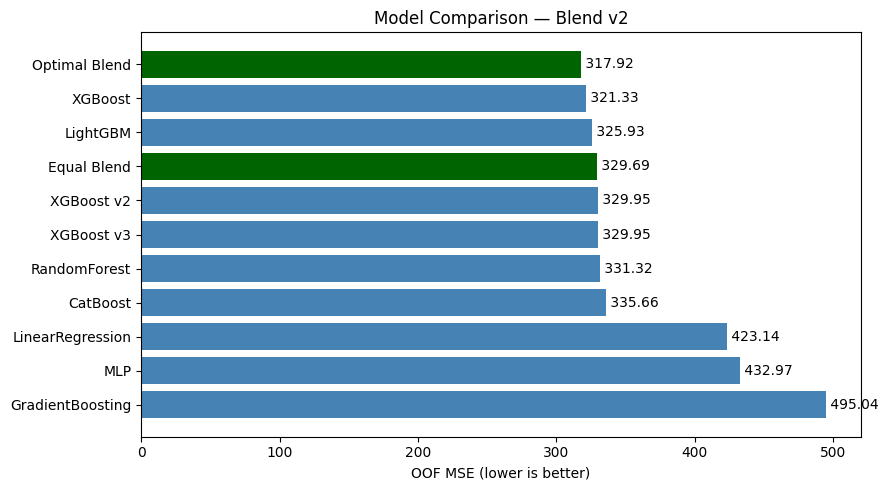

In [6]:
# Comparison plot
scores = {m: mean_squared_error(y, oofs[m]) for m in model_names}
scores['Equal Blend']   = mean_squared_error(y, blend_eq)
scores['Optimal Blend'] = blend_mse(w, oof_mat, y)
s = pd.Series(scores).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in s.index]
ax.barh(s.index, s.values, color=colors)
for i, v in enumerate(s.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()